<a href="https://colab.research.google.com/github/izzat-ai/learning-ai/blob/main/projects/TMDB_Movie_Rating_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Ushbu sahifada kaggledan olingan **The Movie Database (TMDB)** datasetidan foydalanib, filmlarning o'rtacha reytingini (`vote_average`) bashorat qiluvchi Regressiya modeli qurildi. Loyiha ma'lumotlarni tozalashdan boshlab, modelni optimallashtirishgacha bo'lgan to'liq Data Science pipeline-ni o'z ichiga oladi .

- Bundagi biznes foyda : yangi chiqadigan filmning ommabopligi (popularity score) juda yuqori bo'lishini oldindan bashorat qilsa, platforma o'sha filmning namoyish huquqini sotib olish uchun ko'proq budjet ajratadi. Agar past bo'lsa, pulini tejaydi . Qaysi filmlar ommabop bo'lishini bilsak, reklama budjetini to'g'ri taqsimlaymiz. Ommaboplik potensiali yuqori filmlarga ko'proq reklama beriladi

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AI learning/ai_project_2026/Top_rated_movies.csv")
df.head()

,id,title,original_language,original_title,overview,release_date,popularity,vote_count,rating
0,13448,Angels & Demons,en,Angels & Demons,Harvard symbologist Robert Langdon is recruite...,2009-04-20,6.8861,7323,6.719
1,9603,Clueless,en,Clueless,"Shallow, rich and socially successful Cher is ...",1995-07-19,7.5190,4801,7.255
2,6557,27 Dresses,en,27 Dresses,Altruistic Jane finds herself facing her worst...,2008-01-10,5.7786,3421,6.453
3,1333100,Attack on Titan: THE LAST ATTACK,ja,劇場版「進撃の巨人」完結編 THE LAST ATTACK,A colossal-sized omnibus film bringing togethe...,2024-03-20,6.0979,205,8.700
4,578701,Those Who Wish Me Dead,en,Those Who Wish Me Dead,A young boy finds himself pursued by two assas...,2021-05-05,6.2045,1849,6.607


In [ ]:
df2 = pd.read_csv("/content/drive/MyDrive/AI learning/ai_project_2026/movie_data.csv")
df2.head()

,id,title,original_language,overview,release_date,original_title,vote_average,vote_count
0,1339713,Obsession,en,"After breaking the mysterious ""One Wish Willow...",2026-05-13,Obsession,7.900,497
1,1304313,Lee Cronin's The Mummy,en,The young daughter of a journalist disappears ...,2026-04-15,Lee Cronin's The Mummy,8.056,1548
2,1433117,Kara,ta,"A thief tries to go straight, but when predato...",2026-04-30,கர,5.800,14
3,1380291,Tom Clancy's Jack Ryan: Ghost War,en,Jack Ryan is reluctantly pulled back into espi...,2026-05-20,Tom Clancy's Jack Ryan: Ghost War,7.105,457
4,1083381,Backrooms,en,A strange doorway appears in the basement of a...,2026-05-27,Backrooms,6.700,275


##EDA . Datasetni o'rganish

In [ ]:
df.columns

Index(['id', 'title', 'original_language', 'original_title', 'overview',
       'release_date', 'popularity', 'vote_count', 'rating'],
      dtype='object')

In [ ]:
df.shape

(10000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10000 non-null  int64  
 1   title              10000 non-null  object 
 2   original_language  10000 non-null  object 
 3   original_title     10000 non-null  object 
 4   overview           9500 non-null   object 
 5   release_date       10000 non-null  object 
 6   popularity         10000 non-null  float64
 7   vote_count         10000 non-null  int64  
 8   rating             10000 non-null  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 703.3+ KB


1. overview ustunida 500 ta ma'lumotlar yo'q
2. release_date ustuni object turida

In [ ]:
df.describe()

,id,popularity,vote_count,rating
count,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,6.165003e+05,6.433940,2765.800000,6.210350
std,6.230573e+05,0.547213,3236.140405,2.335112
min,9.750000e+02,5.473400,0.000000,0.000000
25%,9.526500e+03,6.087075,160.000000,5.960500
50%,5.127105e+05,6.466050,1383.500000,6.714500
75%,1.186288e+06,6.879800,4263.500000,7.487750
max,1.653208e+06,7.519000,11993.000000,8.700000


In [57]:
# takrorlangan qatorlar soni
df.duplicated().sum()

np.int64(9980)

In [ ]:
print(df.duplicated().sum())

9980


In [ ]:
df.sample(5)

,id,title,original_language,original_title,overview,release_date,popularity,vote_count,rating
9131,8920,Garfield,en,Garfield,"Garfield, the fat, lazy, lasagna lover, has ev...",2004-06-10,6.6964,4242,5.731
1212,893694,Eva,tl,Eva,When Eva gets involved in a steamy threesome w...,2021-12-24,6.2657,25,5.360
8865,1529513,Kong Tao,zh,蛊降,Local property developer Song Longchen secretl...,2026-03-19,5.6685,2,8.500
4701,9603,Clueless,en,Clueless,"Shallow, rich and socially successful Cher is ...",1995-07-19,7.5190,4801,7.255
775,1401586,Sonic the Hedgehog 4,en,Sonic the Hedgehog 4,"Sonic the Hedgehog, joined by a new hero named...",2027-03-11,7.2231,0,0.000


- Yuqorida duplikatlarni aniqladik , ular 9980 ta chiqdi ya'ni takrorlangan ma'lumotlar . Kaggle'dagi bu dataset API orqali yuklanayotganda yoki generatsiya qilinayotganda texnik xatolik tufayli aynan bir xil qatorlar qayta-qayta (yuzlab marta) nusxalanib, pastga qo'shilib ketgan
- Bu muammoni Data Cleaningda tozalab ketamiz

In [ ]:
df['original_language'].value_counts()

,count
original_language,
en,7000
zh,1000
ja,500
tl,500
cn,500
hi,500


In [ ]:
df['title'].value_counts()

,count
title,
Angels & Demons,500
Clueless,500
27 Dresses,500
Attack on Titan: THE LAST ATTACK,500
Those Who Wish Me Dead,500
Kong Tao,500
The Bourne Supremacy,500
Monster House,500
The Eight Hundred,500


- Juda ko'p ma'lumotlar takrorlangan

##Data Cleaning . Ma'lumotlarni tozalash

In [ ]:
df_copy = df.drop_duplicates()
df_copy.shape

(20, 9)

In [ ]:
df_copy.reset_index()

,index,id,title,original_language,original_title,overview,release_date,popularity,vote_count,rating
0,0,13448,Angels & Demons,en,Angels & Demons,Harvard symbologist Robert Langdon is recruite...,2009-04-20,6.8861,7323,6.719
1,1,9603,Clueless,en,Clueless,"Shallow, rich and socially successful Cher is ...",1995-07-19,7.5190,4801,7.255
2,2,6557,27 Dresses,en,27 Dresses,Altruistic Jane finds herself facing her worst...,2008-01-10,5.7786,3421,6.453
3,3,1333100,Attack on Titan: THE LAST ATTACK,ja,劇場版「進撃の巨人」完結編 THE LAST ATTACK,A colossal-sized omnibus film bringing togethe...,2024-03-20,6.0979,205,8.700
4,4,578701,Those Who Wish Me Dead,en,Those Who Wish Me Dead,A young boy finds himself pursued by two assas...,2021-05-05,6.2045,1849,6.607
5,5,1529513,Kong Tao,zh,蛊降,Local property developer Song Longchen secretl...,2026-03-19,5.6685,2,8.500
6,6,2502,The Bourne Supremacy,en,The Bourne Supremacy,A CIA operation to purchase classified Russian...,2004-07-23,6.6624,8158,7.332
7,7,9297,Monster House,en,Monster House,"Monsters under the bed are scary enough, but w...",2006-06-30,6.2944,4328,6.710
8,8,508935,The Eight Hundred,zh,八佰,"In 1937, eight hundred Chinese soldiers fight ...",2020-08-14,5.5712,336,7.000
9,9,1576198,Madulas,en,Madulas,"At the luxurious Wet & Wild Resort, a group of...",2025-11-14,6.4494,1,4.000


- Modelimiz sun'iy ravishda ko'paytirilgan bir xil ma'lumotlarni qayta-qayta ko'rib, "yodlab" olmasligi va haqiqiy qonuniyatlarni o'rganishi uchun faqat toza va noyob qatorlar bilan ishlashimiz shart
- Yuqorida esa atiga 20 ta qator va 9 ta ustunli ma'lumotlar qoldi . Bu Machine Learning modeli qurish uchun mutlaqo yetarsiz
- Demak , ikkinchi faylni tekshiramiz !

##Ikkinchi datasetni tekshirish . EDA - ma'lumotlarni o'rganish

- Loyihamizning Target ustuni - `vote_average` (filmlarning o'rtacha reytingi) bo'ladi .
- Filmlarning o'rtacha reytingini bashorat qilish striming platformalari uchun qaysi film muvaffaqiyat qozonishini oldindan bilishda juda kuchli vosita hisoblanadi .

In [ ]:
df2.head()

,id,title,original_language,overview,release_date,original_title,vote_average,vote_count
0,1339713,Obsession,en,"After breaking the mysterious ""One Wish Willow...",2026-05-13,Obsession,7.900,497
1,1304313,Lee Cronin's The Mummy,en,The young daughter of a journalist disappears ...,2026-04-15,Lee Cronin's The Mummy,8.056,1548
2,1433117,Kara,ta,"A thief tries to go straight, but when predato...",2026-04-30,கர,5.800,14
3,1380291,Tom Clancy's Jack Ryan: Ghost War,en,Jack Ryan is reluctantly pulled back into espi...,2026-05-20,Tom Clancy's Jack Ryan: Ghost War,7.105,457
4,1083381,Backrooms,en,A strange doorway appears in the basement of a...,2026-05-27,Backrooms,6.700,275


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   title              2000 non-null   object 
 2   original_language  2000 non-null   object 
 3   overview           1985 non-null   object 
 4   release_date       1996 non-null   object 
 5   original_title     2000 non-null   object 
 6   vote_average       2000 non-null   float64
 7   vote_count         2000 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 125.1+ KB


- overview ustunida 15 ta NaN bor
- release_date ustunida esa 4 ta NaN bor
- release_date ustuni objectda ekan

In [ ]:
df2.shape

(2000, 8)

In [ ]:
df2.columns

Index(['id', 'title', 'original_language', 'overview', 'release_date',
       'original_title', 'vote_average', 'vote_count'],
      dtype='object')

In [ ]:
df2.duplicated().sum()

np.int64(8)

In [ ]:
# asl dataframedan nusxa olish
df_copy = df2.copy()
df_copy

,id,title,original_language,overview,release_date,original_title,vote_average,vote_count
0,1339713,Obsession,en,"After breaking the mysterious ""One Wish Willow...",2026-05-13,Obsession,7.900,497
1,1304313,Lee Cronin's The Mummy,en,The young daughter of a journalist disappears ...,2026-04-15,Lee Cronin's The Mummy,8.056,1548
2,1433117,Kara,ta,"A thief tries to go straight, but when predato...",2026-04-30,கர,5.800,14
3,1380291,Tom Clancy's Jack Ryan: Ghost War,en,Jack Ryan is reluctantly pulled back into espi...,2026-05-20,Tom Clancy's Jack Ryan: Ghost War,7.105,457
4,1083381,Backrooms,en,A strange doorway appears in the basement of a...,2026-05-27,Backrooms,6.700,275
...,...,...,...,...,...,...,...,...
1995,36955,True Lies,en,"A fearless, globe-trotting, terrorist-battling...",1994-07-15,True Lies,7.096,4575
1996,36669,Die Another Day,en,James Bond is sent to investigate the connecti...,2002-11-17,Die Another Day,5.998,3885
1997,1270125,Monster on a Plane,en,An exotic animal turns into a monster and beco...,2024-11-07,Monster on a Plane,4.778,45
1998,395000,Young Mother 4,ko,"Woo-jin, who is a repeater of college entrance...",2016-04-28,젊은 엄마 4,4.500,12


In [ ]:
# duplikatlarni o'chirish
df_copy = df_copy.drop_duplicates()
df_copy.shape

(1992, 8)

In [ ]:
df_copy.columns

Index(['id', 'title', 'original_language', 'overview', 'release_date',
       'original_title', 'vote_average', 'vote_count'],
      dtype='object')

In [ ]:
# df ning birinchi ustunini indeks qilish
df_copy = df_copy.set_index(df_copy.columns[0]).reset_index()
df_copy

,id,title,original_language,overview,release_date,original_title,vote_average,vote_count
0,1339713,Obsession,en,"After breaking the mysterious ""One Wish Willow...",2026-05-13,Obsession,7.900,497
1,1304313,Lee Cronin's The Mummy,en,The young daughter of a journalist disappears ...,2026-04-15,Lee Cronin's The Mummy,8.056,1548
2,1433117,Kara,ta,"A thief tries to go straight, but when predato...",2026-04-30,கர,5.800,14
3,1380291,Tom Clancy's Jack Ryan: Ghost War,en,Jack Ryan is reluctantly pulled back into espi...,2026-05-20,Tom Clancy's Jack Ryan: Ghost War,7.105,457
4,1083381,Backrooms,en,A strange doorway appears in the basement of a...,2026-05-27,Backrooms,6.700,275
...,...,...,...,...,...,...,...,...
1987,36955,True Lies,en,"A fearless, globe-trotting, terrorist-battling...",1994-07-15,True Lies,7.096,4575
1988,36669,Die Another Day,en,James Bond is sent to investigate the connecti...,2002-11-17,Die Another Day,5.998,3885
1989,1270125,Monster on a Plane,en,An exotic animal turns into a monster and beco...,2024-11-07,Monster on a Plane,4.778,45
1990,395000,Young Mother 4,ko,"Woo-jin, who is a repeater of college entrance...",2016-04-28,젊은 엄마 4,4.500,12


## Data Cleaning - ma'lumotlarni tozalash

In [58]:
# nan qiymatlarni aniqlash
df_copy.isnull().sum()

,0
id,0
title,0
original_language,0
overview,0
release_date,0
original_title,0
vote_average,0
vote_count,0
release_year,0
release_month,0


- overview ustunidagi 15 ta NaN qiymatni tashlab yubormiymiz , balki default qiymatlar bilan to'ldiramiz

In [ ]:
df_copy['overview'] = df_copy['overview'].fillna("No overview available")
df_copy.isnull().sum()

,0
id,0
title,0
original_language,0
overview,0
release_date,4
original_title,0
vote_average,0
vote_count,0


- release_date ustunidagi 4 ta NaN kam bo'lgani uchun ularni o'chiramiz

In [ ]:
# release_date ustunidagi 4 ta NaN bor qatorlarni o'chirish
df_copy = df_copy.dropna(subset=['release_date']).reset_index(drop=True)
df_copy.shape

(1988, 8)

In [ ]:
# release_date ustunini datetime formatiga o'tkizish
df_copy['release_date'] = pd.to_datetime(df_copy['release_date'])
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 1988 non-null   int64         
 1   title              1988 non-null   object        
 2   original_language  1988 non-null   object        
 3   overview           1988 non-null   object        
 4   release_date       1988 non-null   datetime64[ns]
 5   original_title     1988 non-null   object        
 6   vote_average       1988 non-null   float64       
 7   vote_count         1988 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 124.4+ KB


In [ ]:
df_copy.head()

,id,title,original_language,overview,release_date,original_title,vote_average,vote_count
0,1339713,Obsession,en,"After breaking the mysterious ""One Wish Willow...",2026-05-13,Obsession,7.900,497
1,1304313,Lee Cronin's The Mummy,en,The young daughter of a journalist disappears ...,2026-04-15,Lee Cronin's The Mummy,8.056,1548
2,1433117,Kara,ta,"A thief tries to go straight, but when predato...",2026-04-30,கர,5.800,14
3,1380291,Tom Clancy's Jack Ryan: Ghost War,en,Jack Ryan is reluctantly pulled back into espi...,2026-05-20,Tom Clancy's Jack Ryan: Ghost War,7.105,457
4,1083381,Backrooms,en,A strange doorway appears in the basement of a...,2026-05-27,Backrooms,6.700,275


##EDA + Feature Engineering

- Model uchun foydali ustunlar yaratamiz . release_date ustunidan film chiqqan yilni , oyni va hafta kunini olamiz . Chunki model yil-oy-kundan to'ridan tori qonuniyat ajratolmiydi
- Biz oladigan ma'lumotlar esa kinolarning reytingiga tasir qilishi mumkin

In [ ]:
# filmlar chiqqan yillarni olish
df_copy['release_year'] = df_copy['release_date'].dt.year

# oyni olish
df_copy['release_month'] = df_copy['release_date'].dt.month

# hafta kunini olish
df_copy['release_day_week'] = df_copy['release_date'].dt.dayofweek # 0=Dushanba

df_copy.head()

,id,title,original_language,overview,release_date,original_title,vote_average,vote_count,release_year,release_month,release_day_week
0,1339713,Obsession,en,"After breaking the mysterious ""One Wish Willow...",2026-05-13,Obsession,7.900,497,2026,5,2
1,1304313,Lee Cronin's The Mummy,en,The young daughter of a journalist disappears ...,2026-04-15,Lee Cronin's The Mummy,8.056,1548,2026,4,2
2,1433117,Kara,ta,"A thief tries to go straight, but when predato...",2026-04-30,கர,5.800,14,2026,4,3
3,1380291,Tom Clancy's Jack Ryan: Ghost War,en,Jack Ryan is reluctantly pulled back into espi...,2026-05-20,Tom Clancy's Jack Ryan: Ghost War,7.105,457,2026,5,2
4,1083381,Backrooms,en,A strange doorway appears in the basement of a...,2026-05-27,Backrooms,6.700,275,2026,5,2


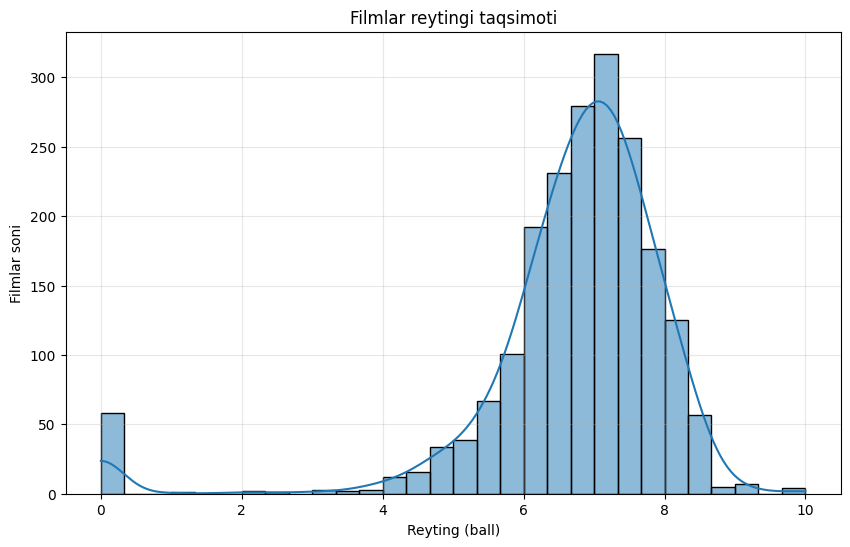

In [ ]:
# Target ustunimiz bo'lgan vote_average (filmlar reytingi) ni taqsimotini ko'ramiz
plt.figure(figsize=(10, 6))
sns.histplot(data=df_copy, x='vote_average', kde=True, bins=30)

plt.title("Filmlar reytingi taqsimoti")
plt.xlabel("Reyting (ball)")
plt.ylabel("Filmlar soni")
plt.grid(True, alpha=0.3)

plt.show()

- Filmlarning juda katta qismi 6 dan 8 ballgacha bo'lgan oraliqda joylashgan
- Eng baland ustun 7.0 - 7.3 ball atrofida bo'lib, aynan shu diapazonga 300 dan ortiq film to'g'ri kelgan
- Grafikning eng chap burchagida, ya'ni 0 ball atrofida kutilmagan o'sish ko'ringan (60 ga yaqin film) . Bu yerda anomal qiymatlar mavjud .

- O'sha 0 ballar — hali hech kim ovoz bermagan (yoki ma'lumotlar bazasiga reytingi kiritilmay qolgan) filmlardir

- 60 ga yaqin ma'lumotlarni o'chirib tashiymiz . Sababi , chiqqan yili , tili har xil bo'lib reytingi bir xil bo'lib qolishi yaxshi emas . Shuning uchun ham ularni to'ldirmasdan o'chirib tashiymiz , shunda ma'lumotlarimiz sifatli bo'ladi

In [ ]:
# 0.5 dan katta ma'lumotlarni olib , qoganini tashavorish
df_copy = df_copy[df_copy['vote_average'] > 0.5].reset_index(drop=True)
df_copy.shape

(1930, 11)

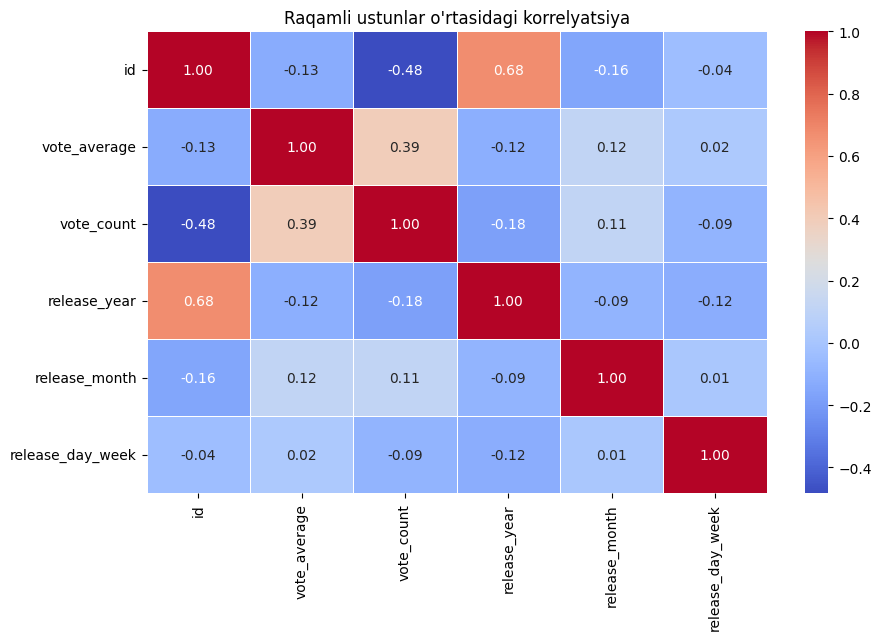

In [ ]:
# qaysi ustun bizning Target ustunimizga kuchli bog'liqligini aniqlash
plt.figure(figsize=(10, 6))

sns.heatmap(data=df_copy.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Raqamli ustunlar o'rtasidagi korrelyatsiya")
plt.show()

- filmga berilgan ovozlar soni qanchalik ko'p bo'lsa, uning reytingi ham yuqoriroq bo'lish tendensiyasiga ega
- Oy va hafta kunlarining nolga yaqin korrelyatsiyasi chiziqli bog'liqlikda deyarli roli yo'qligini bildiradi

##Data Preprocessing - model uchun  ma'lumotlarni tayyorlash

- datasetdagi kategoriyali ustunimiz bo'lgan original_language ni raqamli ko'rinishga o'tkizishimiz kerak

In [ ]:
df_copy['original_language'].value_counts()

,count
original_language,
en,1442
ja,70
ko,64
fr,45
zh,43
es,42
hi,31
it,30
tl,26


- avval 25 tadan kam qatnashgan tillarning barchasini "Other" qilb bitta guruh qilamiz

In [ ]:
# eng ko'p qatnashgan top 10 ta tilni saqlab qolganini other qilish
top_10l = df_copy['original_language'].value_counts().head(10).index
df_copy['original_language'] = df_copy['original_language'].apply(lambda x: x if x in top_10l else 'other')

In [ ]:
df_copy['original_language'].value_counts()

,count
original_language,
en,1442
other,112
ja,70
ko,64
fr,45
zh,43
es,42
hi,31
it,30


In [ ]:
df_encoded = pd.get_dummies(data=df_copy, columns=['original_language'], drop_first=False, dtype=int)
df_encoded.head()

,id,title,overview,release_date,original_title,vote_average,vote_count,release_year,release_month,release_day_week,...,original_language_en,original_language_es,original_language_fr,original_language_hi,original_language_it,original_language_ja,original_language_ko,original_language_other,original_language_tl,original_language_zh
0,1339713,Obsession,"After breaking the mysterious ""One Wish Willow...",2026-05-13,Obsession,7.900,497,2026,5,2,...,1,0,0,0,0,0,0,0,0,0
1,1304313,Lee Cronin's The Mummy,The young daughter of a journalist disappears ...,2026-04-15,Lee Cronin's The Mummy,8.056,1548,2026,4,2,...,1,0,0,0,0,0,0,0,0,0
2,1433117,Kara,"A thief tries to go straight, but when predato...",2026-04-30,கர,5.800,14,2026,4,3,...,0,0,0,0,0,0,0,1,0,0
3,1380291,Tom Clancy's Jack Ryan: Ghost War,Jack Ryan is reluctantly pulled back into espi...,2026-05-20,Tom Clancy's Jack Ryan: Ghost War,7.105,457,2026,5,2,...,1,0,0,0,0,0,0,0,0,0
4,1083381,Backrooms,A strange doorway appears in the basement of a...,2026-05-27,Backrooms,6.700,275,2026,5,2,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
df_encoded.columns

Index(['id', 'title', 'overview', 'release_date', 'original_title',
       'vote_average', 'vote_count', 'release_year', 'release_month',
       'release_day_week', 'original_language_cn', 'original_language_en',
       'original_language_es', 'original_language_fr', 'original_language_hi',
       'original_language_it', 'original_language_ja', 'original_language_ko',
       'original_language_other', 'original_language_tl',
       'original_language_zh'],
      dtype='object')

- Endi ma'lumotlarimiz X (xususiyatlar) va y (bashorat qilinuvchi qiymat) ga ajratamiz . Buning uchun id va matnli ustunlarni shu bilan birga release_date ni ham tashavoramiz , sababi release_datedan kerakli ma'lumotlarni ajratib bo'ldik

In [ ]:
# bashorat qilinuvchi ustunni y qilish
y = df_encoded['vote_average']

# xususiyatlarni ajratish
X = df_encoded.drop(columns=['id', 'title', 'overview', 'release_date', 'original_title', 'vote_average'])

print("x shape=", X.shape)
print("y shape=", y.shape)

x shape= (1930, 15)
y shape= (1930,)


In [ ]:
# modelga kiruvchi yakuniy ustunlar
X.columns.tolist()

['vote_count',
 'release_year',
 'release_month',
 'release_day_week',
 'original_language_cn',
 'original_language_en',
 'original_language_es',
 'original_language_fr',
 'original_language_hi',
 'original_language_it',
 'original_language_ja',
 'original_language_ko',
 'original_language_other',
 'original_language_tl',
 'original_language_zh']

##Train/test split + Model training

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("O'qitish o'chami=", X_train.shape)
print("Test o'lchami=", X_test.shape)

O'qitish o'chami= (1544, 15)
Test o'lchami= (386, 15)


In [ ]:
# Random Forest Regressor modelini yaratish
model = RandomForestRegressor(n_estimators=100, random_state=42)

# modelni o'qitish
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# modelni test qilish
y_pred = model.predict(X_test)

# metrikalarni hisoblash
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [ ]:
print("--- MODEL IMTIHONI NATIJALARI ---")
print(f"R2 Score (Aniqlik darajasi): {r2:.4f}")
print(f"RMSE (O'rtacha xatolik): {rmse:.4f} ball")

--- MODEL IMTIHONI NATIJALARI ---
R2 Score (Aniqlik darajasi): 0.3929
RMSE (O'rtacha xatolik): 0.7687 ball


- Modelimiz har bir filmning reytingini bashorat qilganda , o'rtacha 0.76 ballga adashyapti
- Modelimiz reytinga ta'sir qiluvchi qonunyatlarni qariyb 39% tushungan
- Nima uchun model aniqligi past , yuqori bo'lmadi : sababi filmning muvaffaqiyati ko'proq biz modelga bermagan subyektiv faktorlarga bog'liq , Aktyorlar tarkibi va rejissyor mahorati , Film janri , Ssenariy sifati va marketing byudjeti
- Yuqoridagi faktorlar matnli bo'lgani uchun modelga bermadik

/tmp/ipykernel_312/35205675.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')


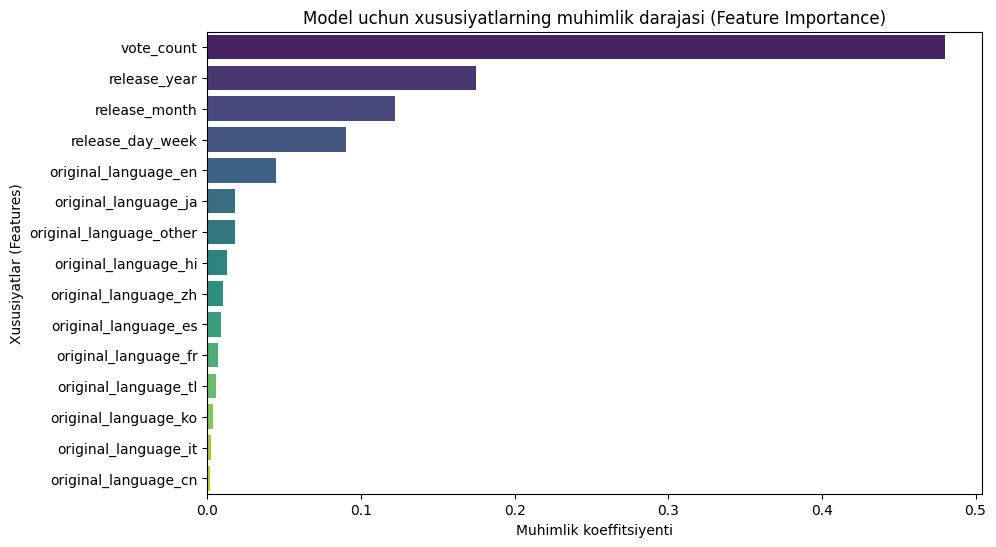

In [ ]:
# model qaysi ustunga tayangan holda bashorat qilganini aniqlash
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')
plt.title('Model uchun xususiyatlarning muhimlik darajasi (Feature Importance)')
plt.xlabel('Muhimlik koeffitsiyenti')
plt.ylabel('Xususiyatlar (Features)')
plt.show()

- Biz EDA bosqichida aniqlagan 0.39% li ko'rsatgich bilan vote_count bilan bog'liqlik boriydi . Modelimiz aynan mana shu ustunga tayangan holda film reytingini bashorat qilishga harakat qildi

In [ ]:
# yangi ma'lumot yaratish | modelimiz bashorat qilishini baholash uchun
yangi_film = pd.DataFrame([{
    'vote_count': 500,
    'release_year': 2026,
    'release_month': 7,
    'release_day_week': 4, # Juma
    'original_language_cn': 0,
    'original_language_en': 1, # Ingliz tili
    'original_language_es': 0,
    'original_language_fr': 0,
    'original_language_hi': 0,
    'original_language_it': 0,
    'original_language_ja': 0,
    'original_language_ko': 0,
    'original_language_other': 0,
    'original_language_tl': 0,
    'original_language_zh': 0
}])

yangi_film = yangi_film[X.columns]
yangi_film

,vote_count,release_year,release_month,release_day_week,original_language_cn,original_language_en,original_language_es,original_language_fr,original_language_hi,original_language_it,original_language_ja,original_language_ko,original_language_other,original_language_tl,original_language_zh
0,500,2026,7,4,0,1,0,0,0,0,0,0,0,0,0


In [ ]:
# bashorat qilish
predicted_rating = model.predict(yangi_film)

print(f"yangi filmning taxminiy reytingi: {predicted_rating[0]:.2f} ball")

yangi filmning taxminiy reytingi: 7.36 ball


- Tashqaridan kelgan yangi ma'lumotlarni modelimiz 10 ballik sistemadan 7.36% izini bashorat qila oldi . Yuqoridagi yangi_filmdagi ma'lumotlar shunchaki hayoliy edi .

## Model aniqligini oshirish . Hyperparameter Tuning

- Random Forest modelida sozlashimiz mumkin bo'lgan giperparametrlar : `n_estimators` - daraxtlar soni , daraxtlar ko'paygani sari model barqarorlashadi . `max_depth` - har bir daraxtning chuqurligi , katta bo'lsa model yodlab oladi . `min_samples_split` - daraxt tugunining ajralishi uchun nechta namuna qolishi kerakligi , `min_samples_leaf` - daraxtning eng ohirgi bargida nechta namuna qolishi kerakligi

- Giperparametrlarni sozlash uchun `RandomizedSearchCV` ni ishlatamiz . Bu biz bergan parametrlardan tasodifiy kombinatsiyalarni tanlab tekshiradi. Bu usul ancha tezroq ishlaydi va ko'pincha eng yaxshi natijaga juda yaqin yechimni topib beradi

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_dist = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8]
}

rf = RandomForestRegressor(random_state=42)

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    random_state=42,
    n_jobs=-1, # Barcha protsessor yadrolaridan foydalanish (tezlashtirish uchun)
    scoring='r2' # R2 scoreni optimallashtirish
)

In [ ]:
print("Eng yaxshi parametrlarni qidirish...")
rf_random.fit(X_train, y_train)
print("Qidiruv yakunlandi")

# Eng yaxshi parametrlarni ko'rish
print("\n--- ENG YAXSHI PARAMETRLAR ---")
print(rf_random.best_params_)

# Eng yaxshi model yordamida test ma'lumotlarini bashorat qilish
best_model = rf_random.best_estimator_
y_pred_tuned = best_model.predict(X_test)

# Yangi metrikalar
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("\n--- SOZLANGAN MODEL NATIJALARI ---")
print(f"Yangi R2 Score: {r2_tuned:.4f}")
print(f"Yangi RMSE: {rmse_tuned:.4f} ball")

Eng yaxshi parametrlarni qidirish...
Qidiruv yakunlandi

--- ENG YAXSHI PARAMETRLAR ---
{'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_depth': None}

--- SOZLANGAN MODEL NATIJALARI ---
Yangi R2 Score: 0.3888
Yangi RMSE: 0.7713 ball


##Xulosa .

Ushbu loyihamizda amalga oshirilgan ishlar :

1. Data Cleaning : bo'sh qiymatlarni tahlil qildik va dublikatlarni tozaladik
2. Outlier Detection: Grafik yordamida anomal "0 ballik" filmlarni topib, ularni o'chirish strategiyasini qildik
3. Feature Engineering: Model tushunishi uchun sana ustunidan yil, oy va kunlarni ajratib oldik
4. Categorical Encoding: Ma'lumotlardagi  tillar muammosini ko'rib, "Top10 + Others" professional yondashuvini qo'lladik
5. Model Training & Evaluation: Ma'lumotlarni Train/Testga ajratib, Random Forest Regressor modelini o'qitdik va uning metrikalarini (R^2, RMSE) tahlil qildik
6. Feature Importance: Model qaysi xususiyatga qarab qaror chiqarayotganini grafikda isbotladik
7. Inference: Butunlay yangi ma'lumot uchun reytingni bashorat qildik
8. RandomizedSearchCV yordamida giperparametrlarni sozlab , model natijalarini yaxshilashga harakat qildik